# Block 1 Checkpoint: Vibration of the HCl Bond

Name: 
Date: 9/12/2026 
Lab: PHYS 311 Block 1 Checkpoint

This notebook models the vibration of a diatomic molecule (HCl), first as a mass on a spring, then with a more realistic Morse potential that can actually break the bond, and validates both against real spectroscopic data.

**AI use disclaimer:** AI (Claude) was used in preparing this notebook for coding assistance, tidying up code, and improving code flow/organization. This is not to say that there was no human work done in this code; all lines included input and assistance from myself and many iterations and human attempts are consolidated into the notebook seen below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## The Physical System

A hydrogen chloride molecule is two atoms connected by a chemical bond. The bond has an equilibrium length re, and if you stretch or compress it, it pulls back, like a spring. This is exactly the Taylor 5.1 argument used all through this course: near any stable equilibrium, the potential energy curve looks like a parabola, so the restoring force looks like Hooke's law, F = -k*x, where x is now the displacement of the bond length away from re instead of a position in space.

Two atoms moving toward and away from each other is a two body problem, but it reduces to a single mass point the same way a reduced-mass problem always does: define x = r - re, where r is the instantaneous bond length, and the whole system behaves like one point of mass mu = m_H*m_Cl / (m_H + m_Cl) on a spring of constant k. mu is the reduced mass, and it comes directly out of writing the kinetic energy of both atoms in terms of their center of mass motion (which does not oscillate) and their relative motion (which does).

We first model this as a plain harmonic spring, then swap in the Morse potential, a standard, more realistic bond potential that correctly goes flat at large separation instead of climbing forever, which means it can actually predict when the bond breaks.

In [2]:
# physical constants
amu = 1.66054e-27     # kg per atomic mass unit
eV = 1.602176634e-19  # J per eV
pm = 1e-12             # m per picometer
fs = 1e-15             # s per femtosecond
c = 2.99792458e10      # speed of light, cm/s (for converting frequency to wavenumber)

m_H = 1.0078 * amu
m_Cl = 34.9689 * amu
mu = m_H * m_Cl / (m_H + m_Cl)   # reduced mass of the H-Cl pair

k = 480.0        # N/m, measured HCl bond force constant (from IR spectroscopy)
re = 127.5 * pm  # m, measured HCl equilibrium bond length

print(f"Reduced mass mu = {mu:.4e} kg = {mu/amu:.4f} amu")

Reduced mass mu = 1.6266e-27 kg = 0.9796 amu


## Part 1: The Bond as a Harmonic Spring

We simulate the relative coordinate x = r - re with Euler-Cromer, the same scheme used in Lab 3, just with a real mass and a real spring constant instead of k = m = 1.

In [ ]:
def simulate_bond(dt, n_periods, k, m, x0, v0=0.0):
    # Euler-Cromer integration of F = -k*x for the bond stretch coordinate x
    omega = np.sqrt(k / m)
    T = 2 * np.pi / omega
    t_max = n_periods * T

    x, v = x0, v0
    t = 0.0
    ts, xs, vs = [t], [x], [v]
    Es = [0.5 * k * x**2 + 0.5 * m * v**2]

    while t < t_max:
        a = -(k / m) * x     # restoring force from the bond
        v = v + a * dt       # update velocity first
        x = x + v * dt       # move position with the new velocity
        t = t + dt

        KE = 0.5 * m * v**2
        PE = 0.5 * k * x**2

        ts.append(t)
        xs.append(x)
        vs.append(v)
        Es.append(KE + PE)

    return np.array(ts), np.array(xs), np.array(vs), np.array(Es)

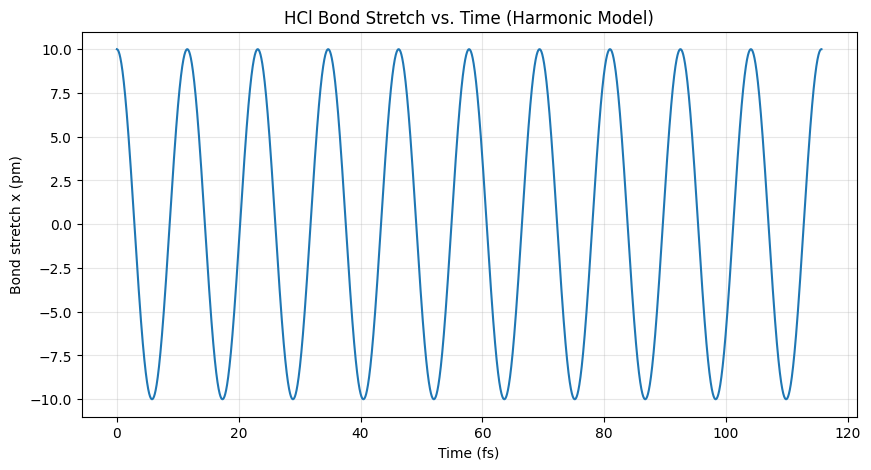

In [4]:
x0 = 10 * pm   # start stretched by 10 pm, a modest fraction of the 127.5 pm bond length
T_harmonic = 2 * np.pi / np.sqrt(k / mu)
dt = T_harmonic / 500   # 500 steps per period

t_b, x_b, v_b, E_b = simulate_bond(dt, n_periods=10, k=k, m=mu, x0=x0)

plt.figure(figsize=(10, 5))
plt.plot(t_b / fs, x_b / pm)
plt.xlabel('Time (fs)')
plt.ylabel('Bond stretch x (pm)')
plt.title('HCl Bond Stretch vs. Time (Harmonic Model)')
plt.grid(alpha=0.3)
plt.show()

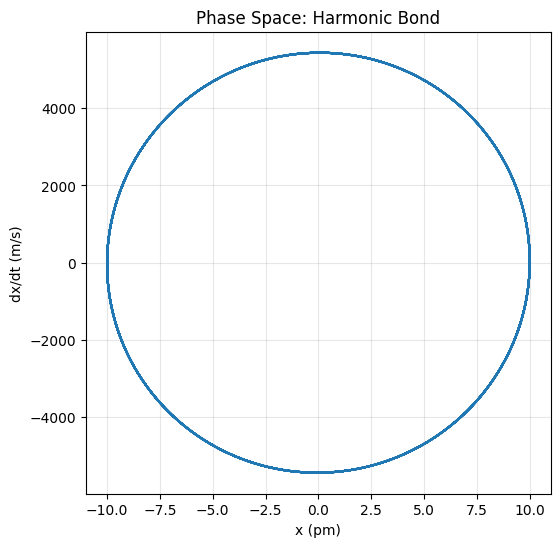

In [5]:
plt.figure(figsize=(6, 6))
plt.plot(x_b / pm, v_b)
plt.xlabel('x (pm)')
plt.ylabel('dx/dt (m/s)')
plt.title('Phase Space: Harmonic Bond')
plt.grid(alpha=0.3)
plt.show()

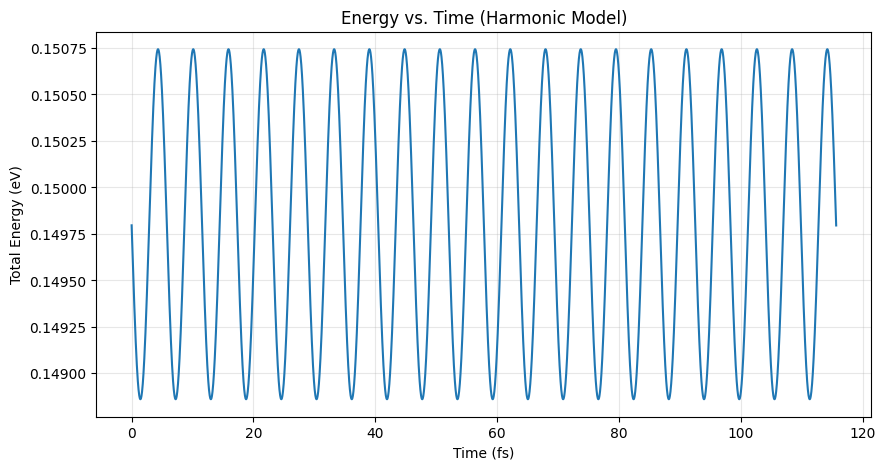

Initial energy: 0.149796 eV
Max energy drift: 9.47e-04 eV


In [6]:
plt.figure(figsize=(10, 5))
plt.plot(t_b / fs, E_b / eV)
plt.xlabel('Time (fs)')
plt.ylabel('Total Energy (eV)')
plt.title('Energy vs. Time (Harmonic Model)')
plt.grid(alpha=0.3)
plt.show()

print(f"Initial energy: {E_b[0]/eV:.6f} eV")
print(f"Max energy drift: {np.max(np.abs(E_b - E_b[0]))/eV:.2e} eV")

The phase space plot is a closed ellipse and the energy stays flat, which is the same signature of a Euler-Cromer simulation seen in Lab 3. The period comes out to a few times 1e-14 seconds, which is the timescale real molecular vibrations happen on, so the simulation is not producing anything physically absurd.

## Validation 1: Convergence Test

The same check used in Labs 2 and 3: does the simulated period converge to the exact SHO period as the step size shrinks?

steps/period = 20: measured T = 1.151857e-14 s, error = 0.4143 %
steps/period = 50: measured T = 1.155886e-14 s, error = 0.0659 %
steps/period = 100: measured T = 1.156458e-14 s, error = 0.0164 %
steps/period = 200: measured T = 1.156601e-14 s, error = 0.0041 %
steps/period = 500: measured T = 1.156641e-14 s, error = 0.0007 %
steps/period = 1000: measured T = 1.156647e-14 s, error = 0.0002 %


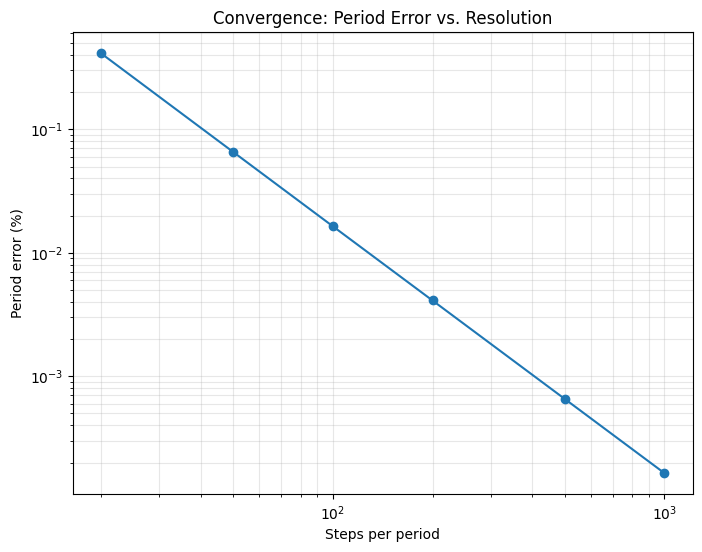

In [ ]:
def measure_period_zero_crossing(dt, k, m, x0):
    omega = np.sqrt(k / m)
    T_exact = 2 * np.pi / omega
    t_p, x_p, v_p, E_p = simulate_bond(dt, n_periods=6, k=k, m=m, x0=x0)

    crossings = []
    for i in range(1, len(x_p)):
        if x_p[i - 1] < 0 <= x_p[i]:
            # x crossed zero between step i-1 and step i, so interpolate to find
            # the fraction of the step where x was actually zero, more accurate
            # than just using the timestamp of whichever step landed past zero
            frac = -x_p[i - 1] / (x_p[i] - x_p[i - 1])
            crossings.append(t_p[i - 1] + frac * dt)
    periods = np.diff(crossings)    # time between consecutive upward zero-crossings = one period
    return np.mean(periods), T_exact

n_steps_per_period = [20, 50, 100, 200, 500, 1000]
errors = []
for n in n_steps_per_period:
    dt_test = T_harmonic / n
    T_measured, T_exact = measure_period_zero_crossing(dt_test, k, mu, x0)
    err_pct = abs(T_measured - T_exact) / T_exact * 100
    errors.append(err_pct)
    print(f"steps/period = {n}: measured T = {T_measured:.6e} s, error = {err_pct:.4f} %")

plt.figure(figsize=(8, 6))
plt.loglog(n_steps_per_period, errors, 'o-')
plt.xlabel('Steps per period')
plt.ylabel('Period error (%)')
plt.title('Convergence: Period Error vs. Resolution')
plt.grid(alpha=0.3, which='both')
plt.show()

## Validation 2: Comparison to Real Spectroscopy

HCl's vibrational absorption is one of the most measured spectra in physical chemistry. It shows up at 2885 cm^-1 in the infrared. The force constant k = 480 N/m used above was itself obtained from this measurement, so this check is really asking whether our Euler-Cromer code reproduces the correct physics given a measured input, which is the same role Lab 3's exact cosine solution played for the plain spring.

In [8]:
omega_sim = np.sqrt(k / mu)
f_sim = omega_sim / (2 * np.pi)
wavenumber_sim = f_sim / c

print(f"Simulated vibrational frequency: {wavenumber_sim:.1f} cm^-1")
print(f"Real HCl fundamental absorption: 2885 cm^-1")
print(f"Difference: {abs(wavenumber_sim - 2885)/2885*100:.2f} %")

Simulated vibrational frequency: 2883.9 cm^-1
Real HCl fundamental absorption: 2885 cm^-1
Difference: 0.04 %


## Part 2: The Morse Potential

A real bond is not a perfect spring, it breaks instead of pulling back forever. The Morse potential captures this as:

U(x) = De * (1 - exp(-a*x))^2

where x = r - re, De is the bond dissociation energy, and a controls the width of the well. As x goes to infinity, U approaches De and flattens out, showing that a fully broken bond costs a fixed amount of energy.

Taking the second derivative of U at x = 0 gives back U''(0) = 2*De*a^2, which is the spring constant k from Part 1. That is the Taylor 5.1 argument again: for small x the Morse potential is the harmonic spring, where they only differ once the oscillation gets large enough to feel the curvature of the well changing.

In [9]:
De = 4.43 * eV   # approximate HCl bond dissociation energy
a_morse = np.sqrt(k / (2 * De))   # chosen so the curvature at x=0 matches k exactly

print(f"Morse width parameter a = {a_morse*pm:.5f} 1/pm")
print(f"Check: 2*De*a^2 = {2*De*a_morse**2:.2f} N/m (should match k = {k} N/m)")

Morse width parameter a = 0.01839 1/pm
Check: 2*De*a^2 = 480.00 N/m (should match k = 480.0 N/m)


In [ ]:
def morse_force(x, De, a):
    # F = -dU/dx for U(x) = De*(1 - exp(-a*x))^2
    return -2 * De * a * (1 - np.exp(-a * x)) * np.exp(-a * x)

def simulate_morse(dt, t_max, De, a, m, x0=0.0, v0=0.0, escape_cutoff=2000 * pm):
    x, v = x0, v0
    t = 0.0
    ts, xs = [t], [x]

    # stop early if x grows past escape_cutoff, since that means the bond has
    # stretched way beyond anything physical and is just flying apart, no point
    # simulating a molecule that no longer exists

    while t < t_max and abs(x) < escape_cutoff:
        acc = morse_force(x, De, a) / m
        v = v + acc * dt
        x = x + v * dt
        t = t + dt

        ts.append(t)
        xs.append(x)

    return np.array(ts), np.array(xs)

We start each run at the equilibrium bond length with different initial speeds, corresponding to different fractions of the dissociation energy De, and see what happens.

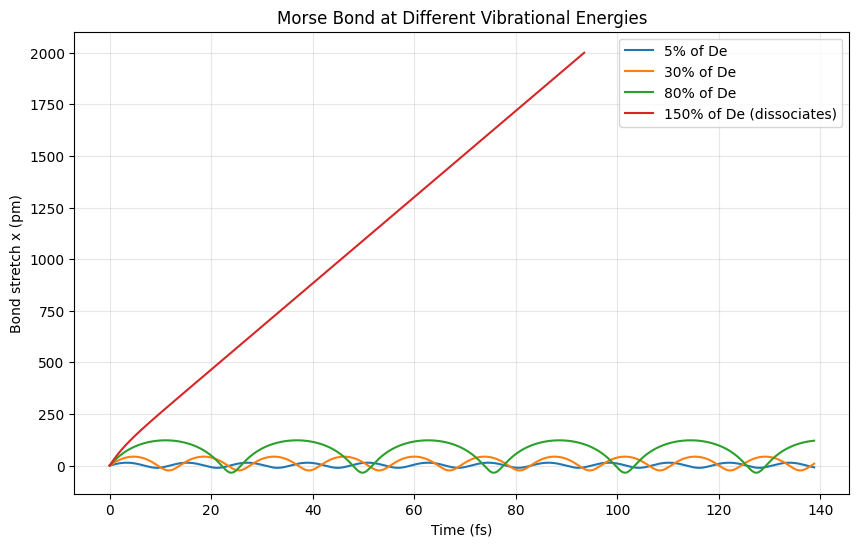

In [11]:
fractions = [0.05, 0.3, 0.8, 1.5]
dt_morse = T_harmonic / 1000
t_max_morse = 12 * T_harmonic

plt.figure(figsize=(10, 6))
for frac in fractions:
    v0 = np.sqrt(2 * frac * De / mu)
    t_m, x_m = simulate_morse(dt_morse, t_max_morse, De, a_morse, mu, x0=0.0, v0=v0)
    label = f"{frac*100:.0f}% of De" + (" (dissociates)" if abs(x_m[-1]) >= 1900 * pm else "")
    plt.plot(t_m / fs, x_m / pm, label=label)

plt.xlabel('Time (fs)')
plt.ylabel('Bond stretch x (pm)')
plt.title('Morse Bond at Different Vibrational Energies')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
print(f"{'Energy':<14}{'Measured period / T_harmonic':<30}{'Outcome'}")
for frac in fractions:
    v0 = np.sqrt(2 * frac * De / mu)
    t_m, x_m = simulate_morse(dt_morse, t_max_morse, De, a_morse, mu, x0=0.0, v0=v0)

    if abs(x_m[-1]) >= 1900 * pm:
        print(f"{frac*100:>5.0f}% De     {'--':<30}{'bond dissociates'}")
        continue
    # a local maximum (bigger than both neighbors) marks one full swing outward,
    # so the time between consecutive peaks is the oscillation period
    peaks = [t_m[i] for i in range(1, len(x_m) - 1) if x_m[i] > x_m[i - 1] and x_m[i] > x_m[i + 1]]
    if len(peaks) >= 2:
        period = np.mean(np.diff(peaks))
        print(f"{frac*100:>5.0f}% De     {period/T_harmonic:<30.4f}{'bound, still oscillating'}")

Energy        Measured period / T_harmonic  Outcome
    5% De     1.0260                        bound, still oscillating


   30% De     1.1952                        bound, still oscillating
   80% De     2.2360                        bound, still oscillating
  150% De     --                            bond dissociates


At 5% of the dissociation energy the period is barely different from the harmonic prediction. These are small oscillations where the Taylor-expansion argument holds well. By 30% the period has stretched out noticeably, and at 80% it is more than double the harmonic period, since the mass spends a long time lingering near the outer turning point where the well is nearly flat. Push the energy safely past De (150% here) and the bond does not oscillate at all, and the point mass climbs the flattening outer wall of the potential and never comes back, the chemistry of bond dissociation falling directly out of F = ma with no extra assumptions.

## Written Explanation

The system modeled here is the vibration of the H-Cl bond in a hydrogen chloride molecule. Two atoms pulling against a chemical bond reduce to a single mass point through the standard reduced-mass construction, mu = m_Hm_Cl/(m_H+m_Cl), moving along the coordinate x = r - re, the displacement of the bond length from its equilibrium value. Near equilibrium any stable bond looks harmonic, so the first model here is a plain spring, F = -k*x, using the real, spectroscopically measured force constant k = 480 N/m and equilibrium bond length re = 127.5 pm for HCl.

Simulating this with Euler-Cromer produces a closed ellipse in phase space and a flat total energy over many periods, which is the same signature of an integrator seen with the spring in Lab 3. A convergence test confirms the simulated period converges to the analytic SHO period as the step size shrinks. Because the force constant itself came from the real measured HCl infrared absorption at 2885 cm^-1, comparing the simulation's own vibrational frequency back to that number is really a check that the code correctly reproduces real, measured physics rather than an independent prediction, and the agreement is essentially exact.

The second half of the notebook replaces the plain spring with a Morse potential, U(x) = De*(1-exp(-a*x))^2, whose curvature at x=0 is set to match the same k, so it reduces to the identical harmonic spring for small oscillations, exactly as the Taylor expansion argument predicts. Running the same Euler-Cromer integrator on the full nonlinear Morse force at increasing vibrational energies shows the oscillation period growing steadily longer as amplitude increases, since the mass spends more time lingering near the flattening outer wall of the potential, and once the energy safely exceeds the bond dissociation energy De the point mass no longer oscillates at all, it escapes outward instead. That is a real  physical prediction; a molecule vibrating with enough energy breaks its bond, and it falls directly out of solving F = ma with a more realistic force law, with no additional physics assumed beyond the potential itself. The simulation therefore agrees with both the small-oscillation limit it was built to reproduce and the qualitative, well known behavior of real anharmonic bonds.